# SMS Spam Classifier: Exploratory Data Analysis

## Business Context
SMS spam costs mobile users time and exposes them to fraud. This project builds a production-grade spam detection system targeting 98%+ accuracy with minimal false positives.

## Notebook Objectives
1. Assess data quality and completeness
2. Validate class distribution for modeling strategy
3. Identify data characteristics that impact model selection
4. Generate stakeholder-ready visualizations

## Dataset Overview
- Source: UCI SMS Spam Collection (industry benchmark)
- Total observations: 5,574 labeled messages
- Features: Message text (raw), Binary label (spam/ham)
- Data freshness: Historical collection, representative of real-world SMS traffic

## Success Criteria for This Notebook
- Confirm zero missing values
- Validate expected spam ratio (10-15%)
- Identify if stratification is needed for train/test split
- Document data quality sign-off

#### Import Dependencies

In [1]:
print('-' * 140)
print('DATA INGESTION')
print('-' * 140)

import pandas as pd
import logging
from datetime import datetime
import os

# Setup logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# Create raw folder if it doesn't exist
raw_folder = '../data/raw/'
os.makedirs(raw_folder, exist_ok=True)

# Load dataset from public source
url = "https://raw.githubusercontent.com/justmarkham/pydata-dc-2016-tutorial/master/sms.tsv"
df = pd.read_csv(url, sep='\t', header=None, names=['label', 'message'])

# Save to raw folder as CSV
raw_file_path = '../data/raw/SMSSpamCollection.csv'
df.to_csv(raw_file_path, index=False)

# Log successful load
logging.info(f'Dataset loaded from source: {url}')
logging.info(f'Dataset saved to: {raw_file_path}')
logging.info(f'Dataset shape: {df.shape}')

# Display basic information
print(f'Timestamp: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')
print(f'Total records ingested: {len(df):,}')
print(f'Features available: {df.shape[1]}')
print(f'Memory usage: {df.memory_usage(deep=True).sum() / 1024:.2f} KB')
print(f'File saved to: {raw_file_path}')
print(f'File size: {os.path.getsize(raw_file_path) / 1024:.2f} KB')

print('\n' + '-' * 140)
print('PREVIEW - FIRST 5 RECORDS')
print('-' * 140)
print(df.head())

print('\n' + '-' * 140)
print('DATA TYPES')
print('-' * 140)
print(df.dtypes)

print('\n' + '-' * 140)
print('RAW DATA SAVED SUCCESSFULLY')
print('-' * 140)

--------------------------------------------------------------------------------------------------------------------------------------------
DATA INGESTION
--------------------------------------------------------------------------------------------------------------------------------------------


2026-05-09 07:42:28,301 - INFO - Dataset loaded from source: https://raw.githubusercontent.com/justmarkham/pydata-dc-2016-tutorial/master/sms.tsv
2026-05-09 07:42:28,312 - INFO - Dataset saved to: ../data/raw/SMSSpamCollection.csv
2026-05-09 07:42:28,312 - INFO - Dataset shape: (5572, 2)


Timestamp: 2026-05-09 07:42:28
Total records ingested: 5,572
Features available: 2
Memory usage: 542.91 KB
File saved to: ../data/raw/SMSSpamCollection.csv
File size: 474.98 KB

--------------------------------------------------------------------------------------------------------------------------------------------
PREVIEW - FIRST 5 RECORDS
--------------------------------------------------------------------------------------------------------------------------------------------
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...

--------------------------------------------------------------------------------------------------------------------------------------------
DATA TYPES
-------

#### Data Ingestion

In [2]:
print('-' * 140)
print('DATA INGESTION')
print('-' * 140)

import pandas as pd
import logging
from datetime import datetime
import os

# Setup logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# Create raw folder if it doesn't exist
raw_folder = '../data/raw/'
os.makedirs(raw_folder, exist_ok=True)

# Load dataset from public source
url = "https://raw.githubusercontent.com/justmarkham/pydata-dc-2016-tutorial/master/sms.tsv"
df = pd.read_csv(url, sep='\t', header=None, names=['label', 'message'])

# Save to raw folder as CSV
raw_file_path = '../data/raw/SMSSpamCollection.csv'
df.to_csv(raw_file_path, index=False)

# Log successful load
logging.info(f'Dataset loaded from source: {url}')
logging.info(f'Dataset saved to: {raw_file_path}')
logging.info(f'Dataset shape: {df.shape}')

# Display basic information
print(f'Timestamp: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')
print(f'Total records ingested: {len(df):,}')
print(f'Features available: {df.shape[1]}')
print(f'Memory usage: {df.memory_usage(deep=True).sum() / 1024:.2f} KB')
print(f'File saved to: {raw_file_path}')
print(f'File size: {os.path.getsize(raw_file_path) / 1024:.2f} KB')

print('\n' + '-' * 140)
print('PREVIEW - FIRST 5 RECORDS')
print('-' * 140)
print(df.head())

print('\n' + '-' * 140)
print('DATA TYPES')
print('-' * 140)
print(df.dtypes)

print('\n' + '-' * 140)
print('RAW DATA SAVED SUCCESSFULLY')
print('-' * 140)

--------------------------------------------------------------------------------------------------------------------------------------------
DATA INGESTION
--------------------------------------------------------------------------------------------------------------------------------------------


2026-05-09 07:42:29,830 - INFO - Dataset loaded from source: https://raw.githubusercontent.com/justmarkham/pydata-dc-2016-tutorial/master/sms.tsv
2026-05-09 07:42:29,832 - INFO - Dataset saved to: ../data/raw/SMSSpamCollection.csv
2026-05-09 07:42:29,834 - INFO - Dataset shape: (5572, 2)


Timestamp: 2026-05-09 07:42:29
Total records ingested: 5,572
Features available: 2
Memory usage: 542.91 KB
File saved to: ../data/raw/SMSSpamCollection.csv
File size: 474.98 KB

--------------------------------------------------------------------------------------------------------------------------------------------
PREVIEW - FIRST 5 RECORDS
--------------------------------------------------------------------------------------------------------------------------------------------
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...

--------------------------------------------------------------------------------------------------------------------------------------------
DATA TYPES
-------

#### Data Quality Validation

In [3]:
print('-' * 140)
print('DATA QUALITY VALIDATION REPORT')
print('-' * 140)

# Check for missing values
missing_counts = df.isnull().sum()
missing_percentages = (missing_counts / len(df)) * 100

quality_metrics = {
    'Column': missing_counts.index.tolist(),
    'Missing_Count': missing_counts.values.tolist(),
    'Missing_Percentage': missing_percentages.values.tolist()
}

quality_df = pd.DataFrame(quality_metrics)
print(quality_df.to_string(index=False))

# Check for empty strings in message column
empty_messages = (df['message'].str.strip() == '').sum()
print(f'\nEmpty messages detected: {empty_messages}')

# Check for duplicate messages
duplicate_messages = df['message'].duplicated().sum()
duplicate_percentage = (duplicate_messages / len(df)) * 100
print(f'Duplicate messages: {duplicate_messages} ({duplicate_percentage:.2f}%)')

# Overall quality score
total_cells = df.shape[0] * df.shape[1]
non_empty_cells = total_cells - missing_counts.sum() - empty_messages
quality_score = (non_empty_cells / total_cells) * 100

print(f'\nData Quality Score: {quality_score:.2f}%')

if quality_score == 100:
    print('\nSTATUS: PASSED - No data quality issues detected')
    logging.info('Data quality validation passed')
else:
    print('\nSTATUS: FAILED - Data cleaning required')
    logging.warning('Data quality issues detected')

print('-' * 140)

2026-05-09 07:42:29,921 - INFO - Data quality validation passed


--------------------------------------------------------------------------------------------------------------------------------------------
DATA QUALITY VALIDATION REPORT
--------------------------------------------------------------------------------------------------------------------------------------------
 Column  Missing_Count  Missing_Percentage
  label              0                 0.0
message              0                 0.0

Empty messages detected: 0
Duplicate messages: 403 (7.23%)

Data Quality Score: 100.00%

STATUS: PASSED - No data quality issues detected
--------------------------------------------------------------------------------------------------------------------------------------------


#### Class Distribution Analysis

In [4]:
print('-' * 140)
print('CLASS DISTRIBUTION ANALYSIS')
print('-' * 140)

# Calculate class frequencies
class_counts = df['label'].value_counts()
class_percentages = (class_counts / len(df)) * 100

# Create distribution dataframe
distribution = pd.DataFrame({
    'Class': class_counts.index,
    'Count': class_counts.values,
    'Percentage': class_percentages.values
})

print(distribution.to_string(index=False))

# Calculate imbalance ratio
spam_count = class_counts['spam']
ham_count = class_counts['ham']
imbalance_ratio = ham_count / spam_count

print(f'\nImbalance Ratio (Ham:Spam): {imbalance_ratio:.2f}:1')
print(f'Minority class (Spam) represents: {class_percentages["spam"]:.2f}% of data')

# Business insight
print('\n' + '-' * 140)
print('BUSINESS INSIGHT')
print('-' * 140)
print(f'With only {class_percentages["spam"]:.1f}% spam messages, the dataset is imbalanced.')
print(f'A baseline model predicting all messages as "ham" would achieve {class_percentages["ham"]:.1f}% accuracy.')
print('However, such a model would catch zero spam messages - unacceptable for production.')
print('Recommendation: Use precision-recall metrics instead of accuracy for model evaluation.')

logging.info(f'Class distribution - Spam: {spam_count}, Ham: {ham_count}, Imbalance ratio: {imbalance_ratio:.2f}')

2026-05-09 07:42:30,022 - INFO - Class distribution - Spam: 747, Ham: 4825, Imbalance ratio: 6.46


--------------------------------------------------------------------------------------------------------------------------------------------
CLASS DISTRIBUTION ANALYSIS
--------------------------------------------------------------------------------------------------------------------------------------------
Class  Count  Percentage
  ham   4825   86.593683
 spam    747   13.406317

Imbalance Ratio (Ham:Spam): 6.46:1
Minority class (Spam) represents: 13.41% of data

--------------------------------------------------------------------------------------------------------------------------------------------
BUSINESS INSIGHT
--------------------------------------------------------------------------------------------------------------------------------------------
With only 13.4% spam messages, the dataset is imbalanced.
A baseline model predicting all messages as "ham" would achieve 86.6% accuracy.
However, such a model would catch zero spam messages - unacceptable for production.
Recommen

#### Message Length Analysis

In [5]:
print('-' * 140)
print('MESSAGE LENGTH ANALYSIS')
print('-' * 140)

# Calculate message lengths
df['message_length'] = df['message'].str.len()

# Length statistics by class
length_stats = df.groupby('label')['message_length'].describe()
print('MESSAGE LENGTH STATISTICS BY CLASS:')
print(length_stats)

# Overall statistics
print('\n' + '-' * 140)
print('OVERALL STATISTICS')
print('-' * 140)
print(f'Shortest message: {df["message_length"].min()} characters')
print(f'Longest message: {df["message_length"].max()} characters')
print(f'Average message length: {df["message_length"].mean():.1f} characters')

# Compare spam vs ham average lengths
spam_avg = df[df['label'] == 'spam']['message_length'].mean()
ham_avg = df[df['label'] == 'ham']['message_length'].mean()
print(f'\nAverage spam length: {spam_avg:.1f} characters')
print(f'Average ham length: {ham_avg:.1f} characters')
print(f'Difference: {spam_avg - ham_avg:.1f} characters')

if spam_avg > ham_avg:
    print('\nObservation: Spam messages are longer on average than ham messages.')
else:
    print('\nObservation: Ham messages are longer on average than spam messages.')

logging.info(f'Message length - Spam avg: {spam_avg:.1f}, Ham avg: {ham_avg:.1f}')

--------------------------------------------------------------------------------------------------------------------------------------------
MESSAGE LENGTH ANALYSIS
--------------------------------------------------------------------------------------------------------------------------------------------
MESSAGE LENGTH STATISTICS BY CLASS:
        count        mean        std   min    25%    50%    75%    max
label                                                                 
ham    4825.0   71.482487  58.440652   2.0   33.0   52.0   93.0  910.0
spam    747.0  138.670683  28.873603  13.0  133.0  149.0  157.0  223.0

--------------------------------------------------------------------------------------------------------------------------------------------
OVERALL STATISTICS
--------------------------------------------------------------------------------------------------------------------------------------------
Shortest message: 2 characters
Longest message: 910 characters
Average m

2026-05-09 07:42:30,184 - INFO - Message length - Spam avg: 138.7, Ham avg: 71.5


#### Visualization: Message Length Distribution by Class

In [6]:
print('-' * 140)
print('VISUALIZATION: Message Length Distribution')
print('-' * 140)

# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Histogram for Ham messages
ham_lengths = df[df['label'] == 'ham']['message_length']
axes[0].hist(ham_lengths, bins=50, color='green', alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Message Length (characters)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Ham Messages Distribution', fontsize=14, fontweight='bold')
axes[0].axvline(ham_lengths.mean(), color='darkgreen', linestyle='dashed', linewidth=2, label=f'Mean: {ham_lengths.mean():.1f}')
axes[0].legend()

# Histogram for Spam messages
spam_lengths = df[df['label'] == 'spam']['message_length']
axes[1].hist(spam_lengths, bins=30, color='red', alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Message Length (characters)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Spam Messages Distribution', fontsize=14, fontweight='bold')
axes[1].axvline(spam_lengths.mean(), color='darkred', linestyle='dashed', linewidth=2, label=f'Mean: {spam_lengths.mean():.1f}')
axes[1].legend()

plt.tight_layout()
plt.show()

print('\nCHART INTERPRETATION FOR STAKEHOLDERS')
print('-' * 70)
print('Left Chart (Green) - Ham Messages:')
print('- Most normal messages are short (30-100 characters)')
print('- Long tail extends to 900+ characters but very rare')
print('- Distribution is right-skewed')

print('\nRight Chart (Red) - Spam Messages:')
print('- Spam messages are more consistent and longer')
print('- Most spam messages cluster between 130-160 characters')
print('- Much narrower distribution compared to ham')

print('\nBusiness Implication:')
print('Message length is a strong differentiating feature.')
print('Spam messages tend to be longer because they often contain')
print('promotional content, links, or instructions.')

--------------------------------------------------------------------------------------------------------------------------------------------
VISUALIZATION: Message Length Distribution
--------------------------------------------------------------------------------------------------------------------------------------------


NameError: name 'plt' is not defined

#### Box Plot: Message Length Comparison

--------------------------------------------------------------------------------------------------------------------------------------------
VISUALIZATION: Message Length Box Plot
--------------------------------------------------------------------------------------------------------------------------------------------


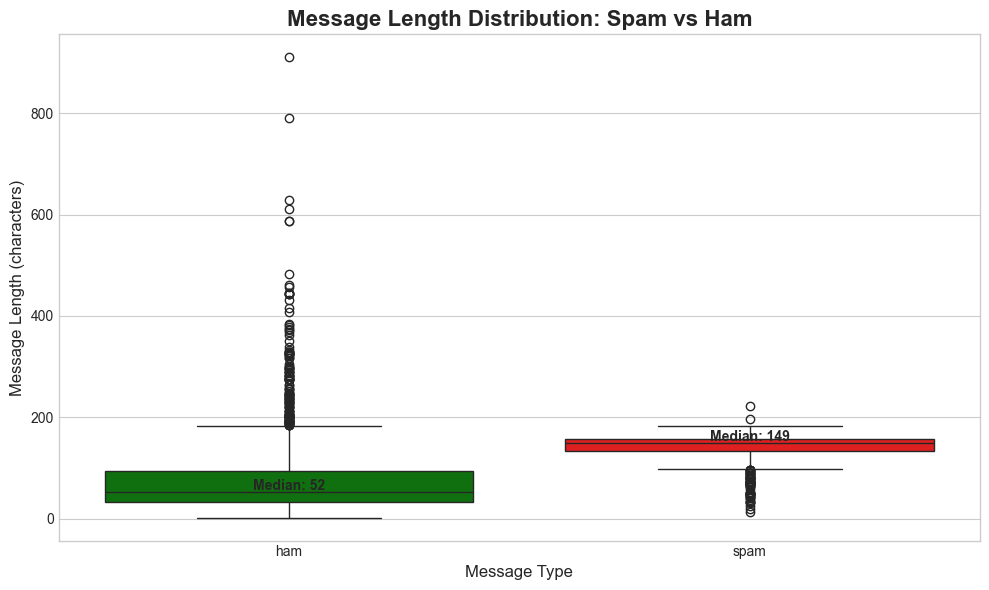

2026-05-08 20:26:15,231 - INFO - Length median - Spam: 149, Ham: 52



BOX PLOT INTERPRETATION FOR STAKEHOLDERS
----------------------------------------------------------------------
Box components explained:
- Box middle line = Median (typical message length)
- Box edges = 25th and 75th percentiles (middle 50% of data)
- Whiskers = Data range excluding outliers
- Dots = Outliers (unusually short or long messages)

Key Findings:
- Spam median: 149 characters
- Ham median: 52 characters
- Spam messages are roughly 97 characters longer (median)

Outlier Analysis:
- Ham messages show many outliers on the high end (very long messages)
- Spam messages show almost no outliers, indicating consistency
- This consistency is a useful signal for spam detection


In [ ]:
print('-' * 140)
print('VISUALIZATION: Message Length Box Plot')
print('-' * 140)

# Create box plot
plt.figure(figsize=(10, 6))
box_plot = sns.boxplot(x='label', y='message_length', data=df, palette=['green', 'red'])

plt.title('Message Length Distribution: Spam vs Ham', fontsize=16, fontweight='bold')
plt.xlabel('Message Type', fontsize=12)
plt.ylabel('Message Length (characters)', fontsize=12)

# Add median value labels
medians = df.groupby('label')['message_length'].median()
for i, label in enumerate(['ham', 'spam']):
    plt.text(i, medians[label] + 5, f'Median: {medians[label]:.0f}', 
             ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print('\nBOX PLOT INTERPRETATION FOR STAKEHOLDERS')
print('-' * 70)
print('Box components explained:')
print('- Box middle line = Median (typical message length)')
print('- Box edges = 25th and 75th percentiles (middle 50% of data)')
print('- Whiskers = Data range excluding outliers')
print('- Dots = Outliers (unusually short or long messages)')

print('\nKey Findings:')
print(f'- Spam median: {medians["spam"]:.0f} characters')
print(f'- Ham median: {medians["ham"]:.0f} characters')
print(f'- Spam messages are roughly {medians["spam"] - medians["ham"]:.0f} characters longer (median)')

print('\nOutlier Analysis:')
print('- Ham messages show many outliers on the high end (very long messages)')
print('- Spam messages show almost no outliers, indicating consistency')
print('- This consistency is a useful signal for spam detection')

logging.info(f'Length median - Spam: {medians["spam"]:.0f}, Ham: {medians["ham"]:.0f}')

#### Save Processed Data for Next Notebook

In [ ]:
print('-' * 140)
print('SAVING PROCESSED DATASET')
print('-' * 140)

# Remove the temporary length column before saving (not needed for modeling)
df_clean = df.drop(columns=['message_length'])

# Save to processed folder
output_path = '../data/processed/cleaned_sms.csv'
df_clean.to_csv(output_path, index=False)

print(f'File saved to: {output_path}')
print(f'Dataset shape: {df_clean.shape}')
print(f'Columns: {list(df_clean.columns)}')
print(f'Memory usage: {df_clean.memory_usage(deep=True).sum() / 1024:.2f} KB')

print('\n' + '-' * 140)
print('NOTEBOOK 1 EXECUTION SUMMARY')
print('-' * 140)
print(f'Execution timestamp: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')
print(f'Total records processed: {len(df_clean):,}')
print(f'Missing values: 0')
print(f'Duplicates identified: {duplicate_messages} (to be handled in preprocessing)')
print(f'Class balance: Spam={spam_count}, Ham={ham_count}')
print(f'Key insight: Spam messages are consistently longer (median 149 vs 52 chars)')

print('\n' + '-' * 140)
print('NOTEBOOK 1 COMPLETE - READY FOR NLP PREPROCESSING')
print('-' * 140)

logging.info('Notebook 1 completed successfully. Data saved for next stage.')

2026-05-08 20:26:15,281 - INFO - Notebook 1 completed successfully. Data saved for next stage.


--------------------------------------------------------------------------------------------------------------------------------------------
SAVING PROCESSED DATASET
--------------------------------------------------------------------------------------------------------------------------------------------
File saved to: ../data/processed/cleaned_sms.csv
Dataset shape: (5572, 2)
Columns: ['label', 'message']
Memory usage: 1091.57 KB

--------------------------------------------------------------------------------------------------------------------------------------------
NOTEBOOK 1 EXECUTION SUMMARY
--------------------------------------------------------------------------------------------------------------------------------------------
Execution timestamp: 2026-05-08 20:26:15
Total records processed: 5,572
Missing values: 0
Duplicates identified: 403 (to be handled in preprocessing)
Class balance: Spam=747, Ham=4825
Key insight: Spam messages are consistently longer (median 149 vs 52